# Clusterización

## Descripción
En esta sección crítica de nuestro análisis exploratorio y preparatorio, la atención se dirige hacia la aplicación de técnicas de aprendizaje no supervisado para la **segmentación de hogares**. Este enfoque es fundamental para abordar el problema de negocio central: la identificación y caracterización de subgrupos de clientes que exhiben patrones de consumo energético distintivos. La capacidad de discernir estos segmentos es esencial para formular estrategias de intervención dirigidas, optimizando la asignación de recursos en programas de eficiencia energética y personalizando ofertas de valor.

### Introducción y Objetivo

El objetivo primordial de esta fase del estudio es **delinear una taxonomía de hogares basada en su perfil de consumo energético**, empleando metodologías que permitan la extracción de estructuras latentes en los datos.

Para lograr este cometido, se implementará una estrategia bifásica que comprende:

1.  **Análisis de Componentes Principales (PCA):** Como paso inicial, se aplicará PCA, una técnica de reducción de dimensionalidad multivariante. El propósito es transformar el espacio de características del dataset de perfiles de hogar (`hogar_perfil`) a un subespacio de menor dimensionalidad, compuesto por componentes principales ortogonales que maximizan la varianza explicada. Esta reducción no solo mitiga la 'maldición de la dimensionalidad', mejorando la eficiencia computacional y la robustez de los algoritmos de clustering, sino que también facilita la visualización e interpretación de las relaciones inherentes entre las variables y los futuros segmentos en un plano bidimensional.

2.  **Clustering K-Means:** Subsiguientemente, sobre el espacio de características transformado por PCA, se aplicará el algoritmo de clustering K-Means. Este método de partición busca agrupar observaciones en `k` clusters, minimizando la suma de las distancias cuadráticas intra-cluster (`SSE`) y maximizando la distancia entre los centroides de los clusters. El resultado esperado es la identificación de 'clusters' o segmentos naturales de hogares, cada uno representando un arquetipo de consumidor con características y necesidades energéticas homogéneas.

La culminación de esta fase será la obtención de una clasificación clara y estadísticamente fundamentada de los segmentos de clientes. Esta segmentación permitirá a la distribuidora de energía desarrollar **políticas y acciones estratégicas diferenciadas y de mayor impacto**, adaptadas a las particularidades de cada grupo de consumidores, desde campañas de concienciación hasta la proposición de soluciones tecnológicas específicas.

# 1.- Importación de librerías

In [58]:
# Importación de librerías
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Carga del dataset y exploración inicial

In [59]:
# Carga del dataset de perfiles
df_profile = pd.read_csv("./data/smart_meters_hogar_perfil.csv")

In [60]:
df_profile.shape

(5384, 13)

In [61]:
df_profile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5384 entries, 0 to 5383
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   LCLid                  5384 non-null   object 
 1   consumo_medio          5384 non-null   float64
 2   consumo_std            5384 non-null   float64
 3   consumo_max            5384 non-null   float64
 4   consumo_invierno       5384 non-null   float64
 5   consumo_verano         5384 non-null   float64
 6   consumo_finde          5384 non-null   float64
 7   consumo_semana         5384 non-null   float64
 8   ratio_invierno_verano  5384 non-null   float64
 9   stdorToU               5384 non-null   object 
 10  Acorn_grouped          5384 non-null   object 
 11  tarifa_enc             5384 non-null   int64  
 12  acorn_enc              5384 non-null   int64  
dtypes: float64(8), int64(2), object(3)
memory usage: 546.9+ KB


In [62]:
df_profile.isna().sum()

LCLid                    0
consumo_medio            0
consumo_std              0
consumo_max              0
consumo_invierno         0
consumo_verano           0
consumo_finde            0
consumo_semana           0
ratio_invierno_verano    0
stdorToU                 0
Acorn_grouped            0
tarifa_enc               0
acorn_enc                0
dtype: int64

In [63]:
df_profile.describe()

,consumo_medio,consumo_std,consumo_max,consumo_invierno,consumo_verano,consumo_finde,consumo_semana,ratio_invierno_verano,tarifa_enc,acorn_enc
count,5384.000000,5384.000000,5384.000000,5384.000000,5384.000000,5384.000000,5384.000000,5384.000000,5384.00000,5384.000000
mean,10.178303,3.872435,27.060777,12.030863,8.235860,10.521794,10.041569,140.661771,0.20338,2.929421
std,7.327760,3.884581,22.128664,9.832609,5.500497,7.415615,7.334408,8238.337430,0.40255,0.793478
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,5.380213,1.663583,13.388750,5.981807,4.577072,5.531405,5.293714,1.111482,0.00000,2.000000
50%,8.335489,2.751953,21.339500,9.429597,7.050611,8.687031,8.215018,1.277518,0.00000,3.000000
75%,12.813572,4.492990,33.681000,14.812013,10.409243,13.304658,12.562853,1.531560,0.00000,4.000000
max,101.366960,61.806950,332.556001,111.226833,87.281598,96.844533,103.156267,582061.108889,1.00000,4.000000


In [64]:
df_profile.duplicated().sum()

np.int64(0)

# 3. Selección de variables:

La variable `LCLid` se excluye del modelo porque solo funciona como identificador del cliente. Las variables `stdorToU` y `Acorn_grouped` se reservan para la interpretación posterior de los clusters. Las variables `tarifa_enc` y `acorn_enc` también se usarán principalmente para perfilamiento, no para el primer modelo de clustering.

In [65]:
id_col = 'LCLid' # Columna de ID única para cada hogar 

# Definición de las características a utilizar para el clustering
features_consumo = [
    'consumo_medio', 
    'consumo_std',
    'consumo_max',
    'consumo_invierno',
    'consumo_verano',
    'consumo_finde',
    'consumo_semana',
    'ratio_invierno_verano'
]

# Características categóricas a incluir (pendiente de revisión)
features_categoricas = [
    'stdorToU',
    'Acorn_grouped',
    'tarifa_enc',
    'acorn_enc'
]

# 4. Identificación y tratamiento de Outliers


La variable `ratio_invierno_verano` presenta valores atípicos extremos. Aunque su mediana es 1.27 y el percentil 75 es 1.53, el valor máximo alcanza 582,061.10. Esto indica que algunos registros tienen un consumo de verano igual o cercano a cero, lo que provoca que el cociente se dispare. Por esta razón, es necesario que se realice un tratamiento, 

In [66]:
#creación de un nuevo dataframe para el modelo de clustering
df_model = df_profile.copy()

# Creación de nuevas características basadas en el consumo
df_model['dif_invierno_verano'] = (
    df_model['consumo_invierno'] - df_model['consumo_verano']
)

# Creación de una característica que representa la proporción entre consumo de invierno y verano
df_model['ratio_invierno_verano_clip'] = df_model['ratio_invierno_verano'].clip(
    upper=df_model['ratio_invierno_verano'].quantile(0.99)
)

Debido a que `ratio_invierno_verano` presenta valores extremos, se creó una variable alternativa llamada `dif_invierno_verano`, calculada como la diferencia entre consumo de invierno y consumo de verano. Esta variable permite capturar el comportamiento estacional de forma más estable. También se creó una versión recortada del ratio al percentil 99 para análisis comparativos.

In [67]:
# Selección de las características numéricas para el clustering modelo A
features_modelo_A = [
    'consumo_medio',
    'consumo_std',
    'consumo_max',
    'consumo_invierno',
    'consumo_verano',
    'consumo_finde',
    'consumo_semana',
    'dif_invierno_verano'
]

X_A = df_model[features_modelo_A].copy()

In [68]:
X_A_clip = X_A.copy()

X_A_clip.describe()

,consumo_medio,consumo_std,consumo_max,consumo_invierno,consumo_verano,consumo_finde,consumo_semana,dif_invierno_verano
count,5384.000000,5384.000000,5384.000000,5384.000000,5384.000000,5384.000000,5384.000000,5384.000000
mean,10.178303,3.872435,27.060777,12.030863,8.235860,10.521794,10.041569,3.795003
std,7.327760,3.884581,22.128664,9.832609,5.500497,7.415615,7.334408,6.569627
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-24.866526
25%,5.380213,1.663583,13.388750,5.981807,4.577072,5.531405,5.293714,0.664083
50%,8.335489,2.751953,21.339500,9.429597,7.050611,8.687031,8.215018,1.862788
75%,12.813572,4.492990,33.681000,14.812013,10.409243,13.304658,12.562853,4.148747
max,101.366960,61.806950,332.556001,111.226833,87.281598,96.844533,103.156267,96.002319


In [69]:
# Tratamiento de outliers para el modelo A utilizando el método de clipping
for col in X_A_clip.columns:
    limite_superior = X_A_clip[col].quantile(0.99)
    X_A_clip[col] = X_A_clip[col].clip(upper=limite_superior)

X_A_clip.describe()

,consumo_medio,consumo_std,consumo_max,consumo_invierno,consumo_verano,consumo_finde,consumo_semana,dif_invierno_verano
count,5384.000000,5384.000000,5384.000000,5384.000000,5384.000000,5384.000000,5384.000000,5384.000000
mean,10.057851,3.801868,26.641281,11.876334,8.136652,10.406959,9.917493,3.686866
std,6.655874,3.432944,19.476293,8.946447,4.901453,6.795359,6.634192,5.832689
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-24.866526
25%,5.380213,1.663583,13.388750,5.981807,4.577072,5.531405,5.293714,0.664083
50%,8.335489,2.751953,21.339500,9.429597,7.050611,8.687031,8.215018,1.862788
75%,12.813572,4.492990,33.681000,14.812013,10.409243,13.304658,12.562853,4.148747
max,36.972975,19.775357,109.812390,51.105190,26.873494,37.043988,36.948918,33.065731


In [70]:
import numpy as np

# Revisar NaN e infinitos en X_A
print("NaN por columna:")
print(X_A_clip.isna().sum())

print("\nInfinitos por columna:")
print(np.isinf(X_A_clip).sum())

print("\nValores máximos:")
print(X_A_clip.max())

NaN por columna:
consumo_medio          0
consumo_std            0
consumo_max            0
consumo_invierno       0
consumo_verano         0
consumo_finde          0
consumo_semana         0
dif_invierno_verano    0
dtype: int64

Infinitos por columna:
consumo_medio          0
consumo_std            0
consumo_max            0
consumo_invierno       0
consumo_verano         0
consumo_finde          0
consumo_semana         0
dif_invierno_verano    0
dtype: int64

Valores máximos:
consumo_medio           36.972975
consumo_std             19.775357
consumo_max            109.812390
consumo_invierno        51.105190
consumo_verano          26.873494
consumo_finde           37.043988
consumo_semana          36.948918
dif_invierno_verano     33.065731
dtype: float64


Para reducir el impacto de valores extremos sobre K-Means, las variables de consumo fueron recortadas al percentil 99. Esta decisión permite conservar la mayoría de los datos, pero limita la influencia de consumos atípicamente altos.

# 5. Estadarización de variables por escalado

In [71]:
from sklearn.preprocessing import StandardScaler

# Escalado de las características para el modelo A
scaler_A = StandardScaler()
X_A_scaled = scaler_A.fit_transform(X_A_clip)

Las variables fueron estandarizadas mediante `StandardScaler`, ya que K-Means utiliza distancias euclidianas y puede verse afectado cuando las variables se encuentran en escalas diferentes.

# 6. Evaluación de K-Means sin PCA

In [72]:
# Importación de librerías para clustering y evaluación
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

resultados_A = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=42
    )
    
    labels = kmeans.fit_predict(X_A_scaled)
    
    resultados_A.append({
        'K': k,
        'Inertia': kmeans.inertia_,
        'Silhouette': silhouette_score(X_A_scaled, labels),
        'Davies_Bouldin': davies_bouldin_score(X_A_scaled, labels)
    })

resultados_A = pd.DataFrame(resultados_A)
resultados_A

/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github

,K,Inertia,Silhouette,Davies_Bouldin
0,2,19732.791108,0.599237,0.775232
1,3,12302.210540,0.488399,0.797503
2,4,9634.031953,0.422594,0.927956
3,5,8192.707165,0.418236,0.958158
4,6,6943.782661,0.381511,0.939432
5,7,6083.523354,0.345336,0.973101
6,8,5466.089533,0.350092,0.963541
7,9,5047.686961,0.311608,0.985891
8,10,4739.305967,0.316769,1.005562


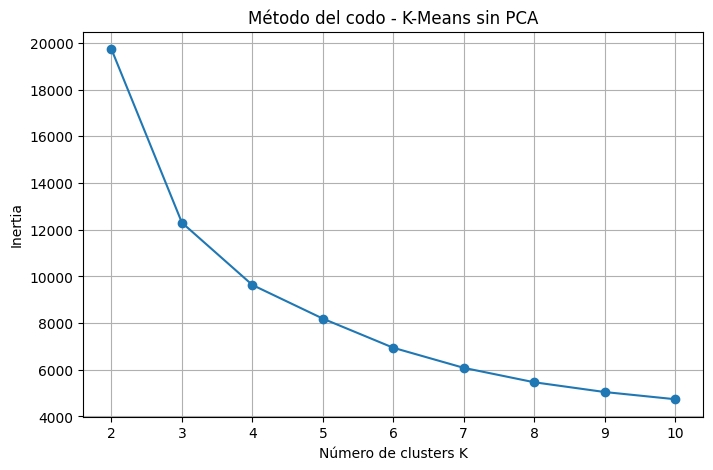

In [73]:
plt.figure(figsize=(8, 5))
plt.plot(resultados_A['K'], resultados_A['Inertia'], marker='o')
plt.xlabel('Número de clusters K')
plt.ylabel('Inertia')
plt.title('Método del codo - K-Means sin PCA')
plt.grid(True)
plt.savefig('./output/images/elbow_kmeans_sin_pca.png', dpi=300, bbox_inches='tight')
plt.show()


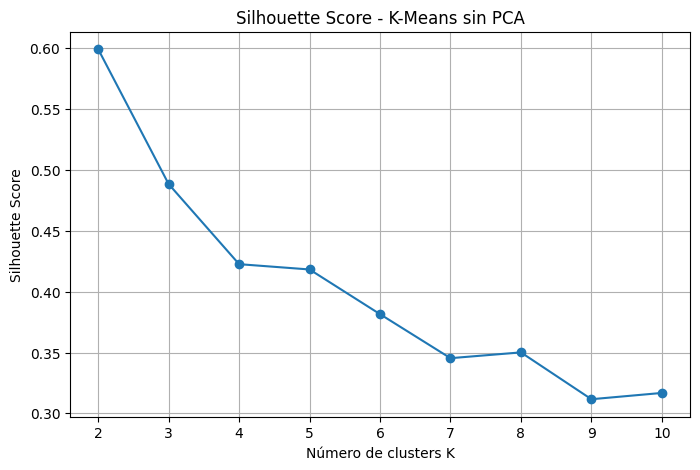

In [74]:
plt.figure(figsize=(8, 5))
plt.plot(resultados_A['K'], resultados_A['Silhouette'], marker='o')
plt.xlabel('Número de clusters K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - K-Means sin PCA')
plt.grid(True)
plt.savefig('./output/images/silhouette_kmeans_sin_pca.png', dpi=300, bbox_inches='tight')
plt.show()

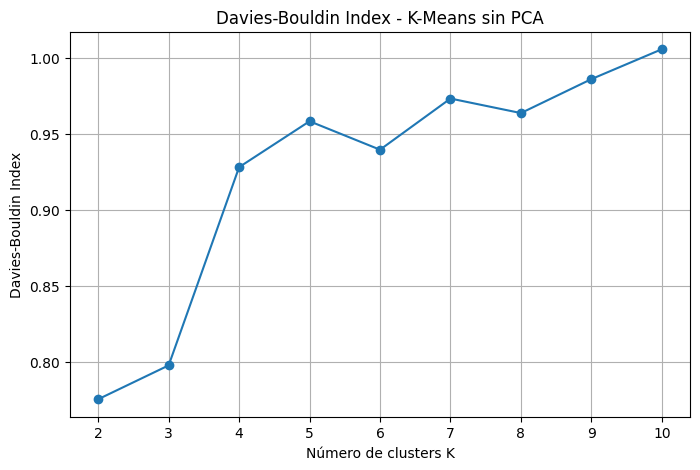

In [75]:
plt.figure(figsize=(8, 5))
plt.plot(resultados_A['K'], resultados_A['Davies_Bouldin'], marker='o')
plt.xlabel('Número de clusters K')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index - K-Means sin PCA')
plt.grid(True)
plt.savefig('./output/images/davies_bouldin_kmeans_sin_pca.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. Evaluación de K-Means con PCA

In [76]:
from sklearn.decomposition import PCA

pca_full = PCA()
X_A_pca_full = pca_full.fit_transform(X_A_scaled)

varianza_pca = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(pca_full.explained_variance_ratio_))],
    'Varianza explicada': pca_full.explained_variance_ratio_,
    'Varianza acumulada': pca_full.explained_variance_ratio_.cumsum()
})

varianza_pca

/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


,Componente,Varianza explicada,Varianza acumulada
0,PC1,0.852899,0.852899
1,PC2,0.104742,0.957640
2,PC3,0.030174,0.987815
3,PC4,0.006732,0.994547
4,PC5,0.002891,0.997437
5,PC6,0.001814,0.999251
6,PC7,0.000747,0.999998
7,PC8,0.000002,1.000000


In [77]:
from sklearn.decomposition import PCA

pca_model = PCA(n_components=2)
X_pca_2 = pca_model.fit_transform(X_A_scaled)

/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


In [78]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd

resultados_pca = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=42,
        algorithm='lloyd'
    )
    
    labels = kmeans.fit_predict(X_pca_2)
    
    resultados_pca.append({
        'K': k,
        'Inertia': kmeans.inertia_,
        'Silhouette': silhouette_score(X_pca_2, labels),
        'Davies_Bouldin': davies_bouldin_score(X_pca_2, labels)
    })

resultados_pca = pd.DataFrame(resultados_pca)
resultados_pca

/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github

,K,Inertia,Silhouette,Davies_Bouldin
0,2,17908.846367,0.617095,0.726542
1,3,10489.175190,0.521083,0.726805
2,4,7826.921111,0.466699,0.820853
3,5,6388.515034,0.462277,0.818788
4,6,5144.770573,0.434757,0.792062
5,7,4288.768107,0.409935,0.808759
6,8,3683.665488,0.416939,0.762992
7,9,3263.685669,0.386195,0.787125
8,10,2993.907699,0.392613,0.799605


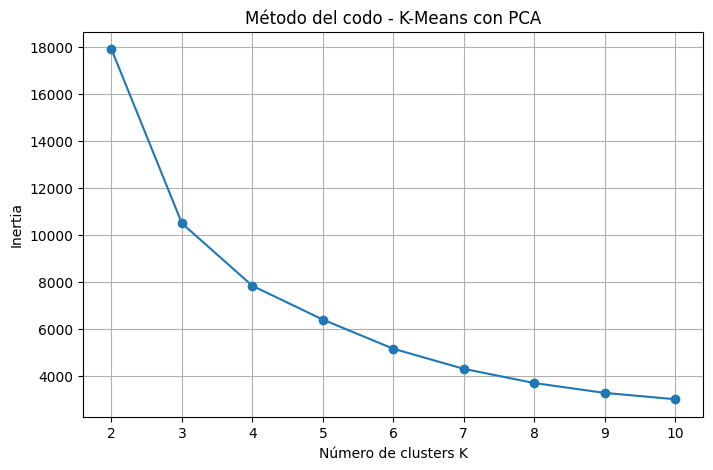

In [79]:
plt.figure(figsize=(8, 5))
plt.plot(resultados_pca['K'], resultados_pca['Inertia'], marker='o')
plt.xlabel('Número de clusters K')
plt.ylabel('Inertia')
plt.title('Método del codo - K-Means con PCA')
plt.grid(True)
plt.savefig('./output/images/elbow_kmeans_con_pca.png', dpi=300, bbox_inches='tight')
plt.show()


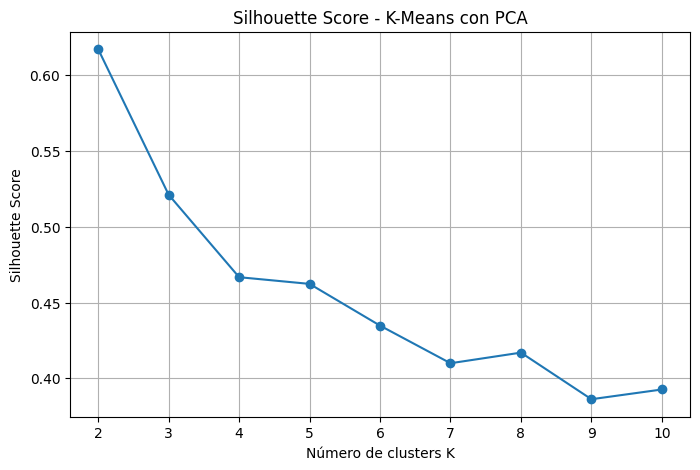

In [80]:
plt.figure(figsize=(8, 5))
plt.plot(resultados_pca['K'], resultados_pca['Silhouette'], marker='o')
plt.xlabel('Número de clusters K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - K-Means con PCA')
plt.grid(True)
plt.savefig('./output/images/silhouette_kmeans_con_pca.png', dpi=300, bbox_inches='tight')
plt.show()

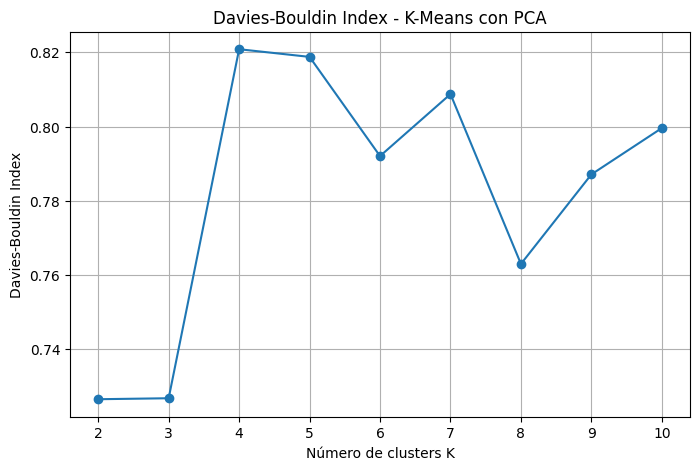

In [81]:
plt.figure(figsize=(8, 5))
plt.plot(resultados_pca['K'], resultados_pca['Davies_Bouldin'], marker='o')
plt.xlabel('Número de clusters K')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index - K-Means con PCA')
plt.grid(True)
plt.savefig('./output/images/davies_bouldin_kmeans_con_pca.png', dpi=300, bbox_inches='tight')
plt.show()

# 8. Comparación de resultados

In [82]:
comparacion = resultados_A.merge(
    resultados_pca,
    on='K',
    suffixes=('_sin_PCA', '_con_PCA')
)

comparacion

,K,Inertia_sin_PCA,Silhouette_sin_PCA,Davies_Bouldin_sin_PCA,Inertia_con_PCA,Silhouette_con_PCA,Davies_Bouldin_con_PCA
0,2,19732.791108,0.599237,0.775232,17908.846367,0.617095,0.726542
1,3,12302.210540,0.488399,0.797503,10489.175190,0.521083,0.726805
2,4,9634.031953,0.422594,0.927956,7826.921111,0.466699,0.820853
3,5,8192.707165,0.418236,0.958158,6388.515034,0.462277,0.818788
4,6,6943.782661,0.381511,0.939432,5144.770573,0.434757,0.792062
5,7,6083.523354,0.345336,0.973101,4288.768107,0.409935,0.808759
6,8,5466.089533,0.350092,0.963541,3683.665488,0.416939,0.762992
7,9,5047.686961,0.311608,0.985891,3263.685669,0.386195,0.787125
8,10,4739.305967,0.316769,1.005562,2993.907699,0.392613,0.799605


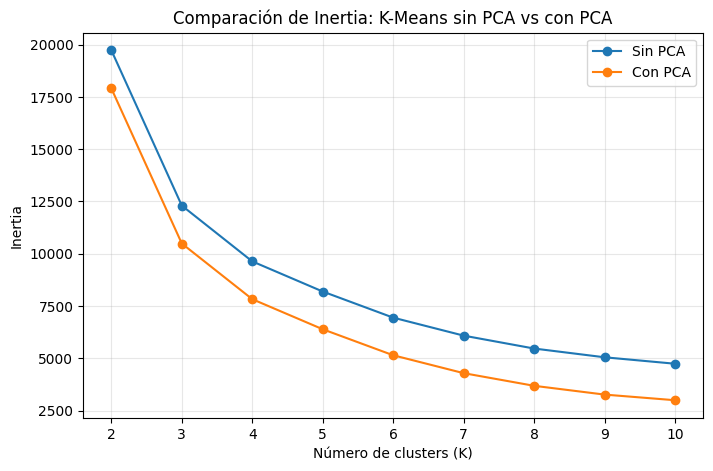

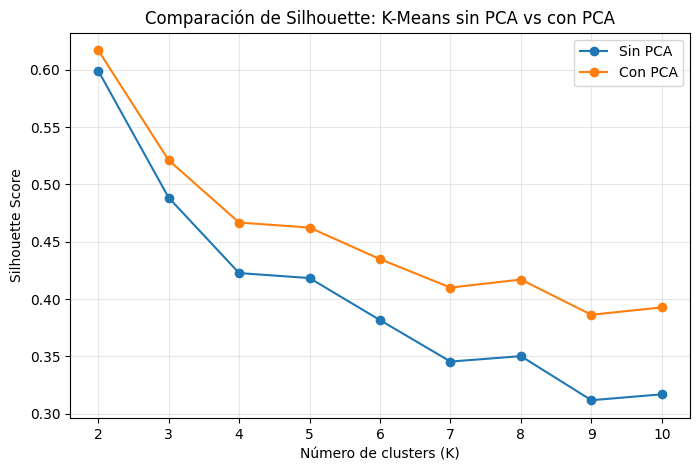

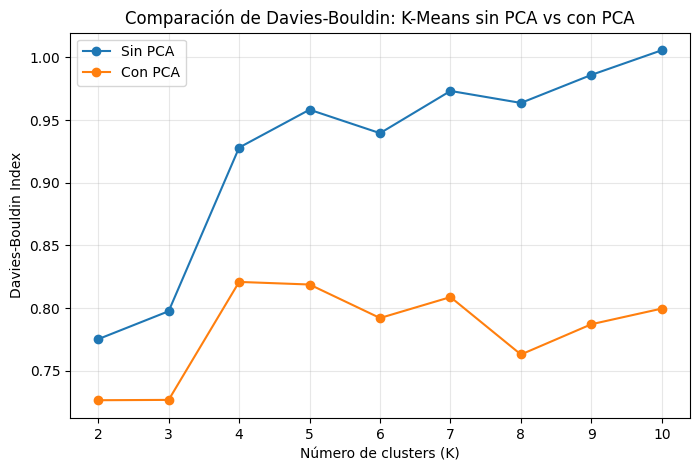

In [83]:
# Asegurar orden por K
comparacion = comparacion.sort_values('K')

# =========================
# Gráfica 1: Inertia
# =========================
plt.figure(figsize=(8, 5))
plt.plot(comparacion['K'], comparacion['Inertia_sin_PCA'], marker='o', label='Sin PCA')
plt.plot(comparacion['K'], comparacion['Inertia_con_PCA'], marker='o', label='Con PCA')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inertia')
plt.title('Comparación de Inertia: K-Means sin PCA vs con PCA')
plt.xticks(comparacion['K'])
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('./output/images/comparacion_kmeans_inertia_sin_con_pca.png', dpi=300, bbox_inches='tight')
plt.show()

# =========================
# Gráfica 2: Silhouette
# =========================
plt.figure(figsize=(8, 5))
plt.plot(comparacion['K'], comparacion['Silhouette_sin_PCA'], marker='o', label='Sin PCA')
plt.plot(comparacion['K'], comparacion['Silhouette_con_PCA'], marker='o', label='Con PCA')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Comparación de Silhouette: K-Means sin PCA vs con PCA')
plt.xticks(comparacion['K'])
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('./output/images/comparacion_kmeans_silhouette_sin_con_pca.png', dpi=300, bbox_inches='tight')
plt.show()

# =========================
# Gráfica 3: Davies-Bouldin
# =========================
plt.figure(figsize=(8, 5))
plt.plot(comparacion['K'], comparacion['Davies_Bouldin_sin_PCA'], marker='o', label='Sin PCA')
plt.plot(comparacion['K'], comparacion['Davies_Bouldin_con_PCA'], marker='o', label='Con PCA')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Davies-Bouldin Index')
plt.title('Comparación de Davies-Bouldin: K-Means sin PCA vs con PCA')
plt.xticks(comparacion['K'])
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('./output/images/comparacion_kmeans_davies_bouldin_sin_con_pca.png', dpi=300, bbox_inches='tight')
plt.show()

In [84]:
comparacion_mejorada = comparacion.copy()

# Diferencias
comparacion_mejorada['Delta_Inertia'] = (
    comparacion_mejorada['Inertia_con_PCA'] - comparacion_mejorada['Inertia_sin_PCA']
)

comparacion_mejorada['Delta_Silhouette'] = (
    comparacion_mejorada['Silhouette_con_PCA'] - comparacion_mejorada['Silhouette_sin_PCA']
)

# Aquí positivo significa mejora con PCA porque Davies-Bouldin debe ser menor
comparacion_mejorada['Mejora_Davies_Bouldin'] = (
    comparacion_mejorada['Davies_Bouldin_sin_PCA'] - comparacion_mejorada['Davies_Bouldin_con_PCA']
)

# Reducción porcentual de Inertia
comparacion_mejorada['Reduccion_%_Inertia'] = (
    (comparacion_mejorada['Inertia_sin_PCA'] - comparacion_mejorada['Inertia_con_PCA'])
    / comparacion_mejorada['Inertia_sin_PCA'] * 100
)

comparacion_mejorada = comparacion_mejorada[[
    'K',
    'Inertia_sin_PCA', 'Inertia_con_PCA', 'Reduccion_%_Inertia',
    'Silhouette_sin_PCA', 'Silhouette_con_PCA', 'Delta_Silhouette',
    'Davies_Bouldin_sin_PCA', 'Davies_Bouldin_con_PCA', 'Mejora_Davies_Bouldin'
]]

comparacion_mejorada.round(4)

,K,Inertia_sin_PCA,Inertia_con_PCA,Reduccion_%_Inertia,Silhouette_sin_PCA,Silhouette_con_PCA,Delta_Silhouette,Davies_Bouldin_sin_PCA,Davies_Bouldin_con_PCA,Mejora_Davies_Bouldin
0,2,19732.7911,17908.8464,9.2432,0.5992,0.6171,0.0179,0.7752,0.7265,0.0487
1,3,12302.2105,10489.1752,14.7375,0.4884,0.5211,0.0327,0.7975,0.7268,0.0707
2,4,9634.0320,7826.9211,18.7576,0.4226,0.4667,0.0441,0.9280,0.8209,0.1071
3,5,8192.7072,6388.5150,22.0219,0.4182,0.4623,0.0440,0.9582,0.8188,0.1394
4,6,6943.7827,5144.7706,25.9082,0.3815,0.4348,0.0532,0.9394,0.7921,0.1474
5,7,6083.5234,4288.7681,29.5019,0.3453,0.4099,0.0646,0.9731,0.8088,0.1643
6,8,5466.0895,3683.6655,32.6088,0.3501,0.4169,0.0668,0.9635,0.7630,0.2005
7,9,5047.6870,3263.6857,35.3429,0.3116,0.3862,0.0746,0.9859,0.7871,0.1988
8,10,4739.3060,2993.9077,36.8281,0.3168,0.3926,0.0758,1.0056,0.7996,0.2060


## Selección de la mejor K

Con base en los resultados obtenidos, la mejor opción es **K = 3**, ya que representa el mejor equilibrio entre calidad del agrupamiento, separación entre clusters e interpretabilidad del modelo.

Aunque **K = 2** presenta el valor más alto de **Silhouette con PCA** con un valor de **0.6171**, esta segmentación puede ser demasiado general, ya que divide los datos únicamente en dos grupos. Esto podría ocultar patrones relevantes dentro del conjunto de datos.

Por otro lado, **K = 3** mantiene un desempeño sólido:

| K | Inertia con PCA | Silhouette con PCA | Davies-Bouldin con PCA |
|---|---:|---:|---:|
| 2 | 17908.8464 | **0.6171** | **0.7265** |
| 3 | 10489.1752 | 0.5211 | 0.7268 |
| 4 | 7826.9211 | 0.4667 | 0.8209 |
| 5 | 6388.5150 | 0.4623 | 0.8188 |

Al pasar de **K = 2** a **K = 3**, la inertia disminuye de **17908.8464** a **10489.1752**, lo que indica una mejora importante en la compactación de los clusters. Además, el índice **Davies-Bouldin con PCA** para K = 3 es de **0.7268**, prácticamente igual al de K = 2, lo que muestra que la separación entre grupos se mantiene adecuada.

A partir de **K = 4**, el valor de **Silhouette** comienza a disminuir de forma progresiva, lo cual sugiere que los clusters pierden cohesión y separación. Aunque la inertia sigue bajando conforme aumenta K, esta reducción es esperada en K-Means y no necesariamente implica una mejor segmentación.

### Conclusión

Se selecciona **K = 3** como el número óptimo de clusters, porque ofrece una segmentación más informativa que K = 2 sin sacrificar significativamente la calidad del modelo. Además, mantiene un buen equilibrio entre compactación, separación e interpretabilidad, mientras que valores mayores de K muestran una disminución en la calidad de los clusters según la métrica Silhouette.

# 9. Entrenamiento con K = 3

In [85]:
# =========================
# 1. PCA final con 2 componentes
# =========================
pca_final = PCA(n_components=2)
X_pca_final = pca_final.fit_transform(X_A_scaled)

print("Varianza explicada por PC1 y PC2:")
print(pca_final.explained_variance_ratio_)

print("Varianza acumulada:")
print(pca_final.explained_variance_ratio_.sum())

# =========================
# 2. Entrenar K-Means final
# =========================
k_final = 3

kmeans_final = KMeans(
    n_clusters=k_final,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42,
    algorithm='lloyd'
)

labels_final = kmeans_final.fit_predict(X_pca_final)

# =========================
# 3. Guardar cluster en el dataframe
# =========================
df_model['cluster'] = labels_final

# =========================
# 4. Guardar componentes PCA para visualización
# =========================
df_model['PC1'] = X_pca_final[:, 0]
df_model['PC2'] = X_pca_final[:, 1]

df_model.head()

Varianza explicada por PC1 y PC2:
[0.85289863 0.10474168]
Varianza acumulada:
0.9576403154642167


/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/m

,LCLid,consumo_medio,consumo_std,consumo_max,consumo_invierno,consumo_verano,consumo_finde,consumo_semana,ratio_invierno_verano,stdorToU,Acorn_grouped,tarifa_enc,acorn_enc,dif_invierno_verano,ratio_invierno_verano_clip,cluster,PC1,PC2
0,MAC000002,12.093578,4.517378,39.284,13.203778,9.141011,12.863732,11.786382,1.444455,Std,Affluent,0,3,4.062767,1.444455,1,0.795526,-0.067311
1,MAC000003,19.031318,11.641836,50.759,27.928126,12.229174,18.791663,19.126267,2.283729,Std,Adversity,0,2,15.698952,2.283729,2,4.281830,1.206709
2,MAC000004,1.694603,0.431671,7.354,1.837633,1.522543,1.738516,1.677188,1.206949,Std,Affluent,0,3,0.315090,1.206949,0,-3.130898,0.542917
3,MAC000005,4.561994,1.473369,16.708,5.537317,3.676062,4.577333,4.555871,1.506317,ToU,Affluent,1,3,1.861255,1.506317,0,-2.000436,0.426491
4,MAC000006,2.842744,0.882945,6.636,2.985642,2.462321,2.727290,2.888498,1.212531,Std,Adversity,0,2,0.523322,1.212531,0,-2.789907,0.410972


In [86]:
silhouette_final = silhouette_score(X_pca_final, labels_final)
davies_final = davies_bouldin_score(X_pca_final, labels_final)
inertia_final = kmeans_final.inertia_

print("Resultados del modelo final:")
print(f"K final: {k_final}")
print(f"Inertia: {inertia_final:.4f}")
print(f"Silhouette Score: {silhouette_final:.4f}")
print(f"Davies-Bouldin Index: {davies_final:.4f}")

Resultados del modelo final:
K final: 3
Inertia: 10489.1752
Silhouette Score: 0.5211
Davies-Bouldin Index: 0.7268


/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/pyt

In [87]:
distribucion_clusters = df_model['cluster'].value_counts().sort_index()

distribucion_porcentaje = (
    df_model['cluster'].value_counts(normalize=True).sort_index() * 100
)

tabla_distribucion = pd.DataFrame({
    'clientes': distribucion_clusters,
    'porcentaje': distribucion_porcentaje.round(2)
})

tabla_distribucion

,clientes,porcentaje
cluster,,
0,3284,61.00
1,1738,32.28
2,362,6.72


In [88]:
perfil_clusters = df_model.groupby('cluster')[features_modelo_A].mean()

perfil_clusters

,consumo_medio,consumo_std,consumo_max,consumo_invierno,consumo_verano,consumo_finde,consumo_semana,dif_invierno_verano
cluster,,,,,,,,
0,6.034111,2.086065,16.126539,6.704884,5.348760,6.267885,5.941102,1.356124
1,14.079087,5.049193,36.310140,16.454286,11.546919,14.685494,13.837685,4.907367
2,29.045600,14.428324,81.847086,39.109883,18.530380,29.122148,29.014720,20.579503


In [89]:
perfil_clusters_completo = df_model.groupby('cluster')[
    features_modelo_A + [
        'ratio_invierno_verano_clip',
        'tarifa_enc',
        'acorn_enc'
    ]
].mean()

perfil_clusters_completo.round(3)

,consumo_medio,consumo_std,consumo_max,consumo_invierno,consumo_verano,consumo_finde,consumo_semana,dif_invierno_verano,ratio_invierno_verano_clip,tarifa_enc,acorn_enc
cluster,,,,,,,,,,,
0,6.034,2.086,16.127,6.705,5.349,6.268,5.941,1.356,1.308,0.215,2.866
1,14.079,5.049,36.310,16.454,11.547,14.685,13.838,4.907,1.549,0.188,3.033
2,29.046,14.428,81.847,39.110,18.530,29.122,29.015,20.580,2.565,0.174,3.006


In [90]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

silhouette_final = silhouette_score(X_pca_final, labels_final)
davies_final = davies_bouldin_score(X_pca_final, labels_final)
inertia_final = kmeans_final.inertia_

print("Resultados del modelo final:")
print(f"K final: {k_final}")
print(f"Inertia: {inertia_final:.4f}")
print(f"Silhouette Score: {silhouette_final:.4f}")
print(f"Davies-Bouldin Index: {davies_final:.4f}")

Resultados del modelo final:
K final: 3
Inertia: 10489.1752
Silhouette Score: 0.5211
Davies-Bouldin Index: 0.7268


/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/malgeak/Documents/Anahuac/Machine Learning/Proyecto Final/github/SmartEnergy_Analytics/.venv/lib/pyt

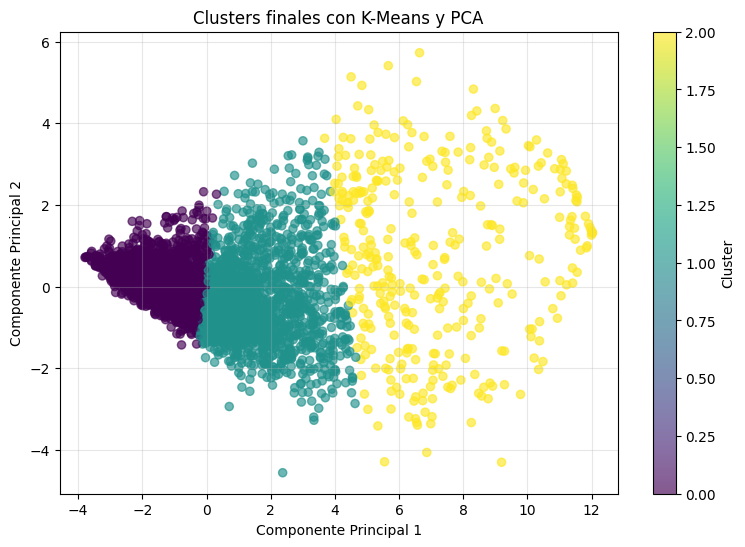

In [91]:
plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df_model['PC1'],
    df_model['PC2'],
    c=df_model['cluster'],
    alpha=0.65,
    s=35
)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clusters finales con K-Means y PCA')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

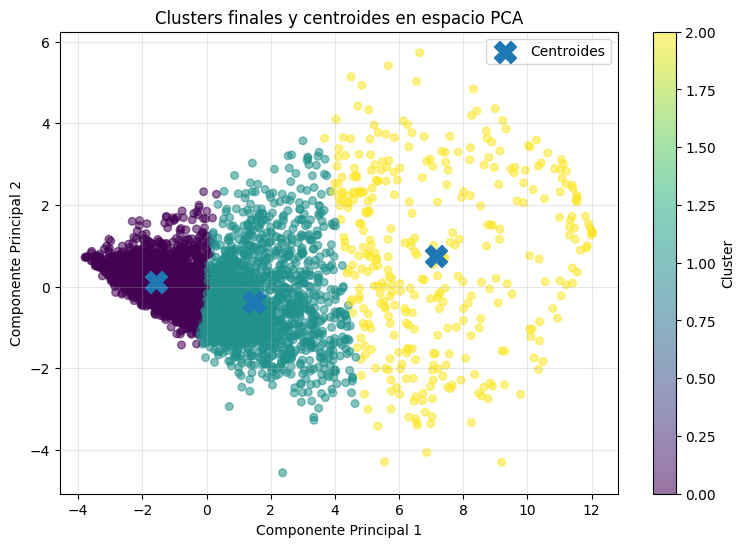

In [92]:
centroides_pca = kmeans_final.cluster_centers_

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    df_model['PC1'],
    df_model['PC2'],
    c=df_model['cluster'],
    alpha=0.55,
    s=30
)

plt.scatter(
    centroides_pca[:, 0],
    centroides_pca[:, 1],
    s=250,
    marker='X',
    label='Centroides'
)

plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clusters finales y centroides en espacio PCA')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [93]:
resumen_final = pd.DataFrame({
    'Métrica': [
        'K seleccionado',
        'Inertia',
        'Silhouette Score',
        'Davies-Bouldin Index',
        'Varianza explicada PCA'
    ],
    'Valor': [
        k_final,
        round(inertia_final, 4),
        round(silhouette_final, 4),
        round(davies_final, 4),
        round(pca_final.explained_variance_ratio_.sum(), 4)
    ]
})

resumen_final

,Métrica,Valor
0,K seleccionado,3.0000
1,Inertia,10489.1752
2,Silhouette Score,0.5211
3,Davies-Bouldin Index,0.7268
4,Varianza explicada PCA,0.9576
